In [1]:
import pandas as pd 

df = pd.read_csv("../data/sales.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
#Check missing value
df.isna().sum().sort_values(ascending=False)

Ship Date        5985
Order Date       5841
Postal Code        11
Row ID              0
Order ID            0
Ship Mode           0
Customer Name       0
Segment             0
Country             0
Customer ID         0
City                0
State               0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
dtype: int64

In [7]:
#Check duplicate
df.duplicated().sum()

np.int64(0)

In [8]:
#remove duplicate
df = df.drop_duplicates()

In [10]:
#check data types
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [11]:
# check missing values again for important columns
df[["Order Date", "Ship Date", "Region", "Category", "Sub-Category", "Product Name", "Sales"]].isna().sum()

Order Date      5841
Ship Date       5985
Region             0
Category           0
Sub-Category       0
Product Name       0
Sales              0
dtype: int64

In [13]:
# clean dataframe
df_clean = df.copy()

In [15]:
#standardize text column 
text_cols = ["Segment", "Country", "City", "State", "Region", "Category", "Sub-Category", "Product Name"]

for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [16]:
#convert dates and sales to clean dataframe
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"], errors="coerce")
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"], errors="coerce")
df_clean["Sales"] = pd.to_numeric(df_clean["Sales"], errors="coerce")

In [17]:
#drop missing row
df_clean = df_clean.dropna(subset=["Order Date", "Sales", "Region", "Category"])

In [18]:
#create times column
df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M").astype(str)

In [19]:
#VALIDATE
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean[["Order Date", "Ship Date", "Region", "Category", "Sub-Category", "Product Name", "Sales"]].isna().sum())
print("\nSample:")
df_clean.head()

Shape: (3959, 22)

Missing values:
Order Date         0
Ship Date       1283
Region             0
Category           0
Sub-Category       0
Product Name       0
Sales              0
dtype: int64

Sample:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Month Name,Year-Month
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,8,August,2017-08
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,8,August,2017-08
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,12,December,2017-12
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,11,November,2016-11
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,11,November,2016-11


In [ ]:
#save the clean dataset
df_clean.to_csv("../data/sales_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
#monthly sales trend
monthly_sales = (
    df_clean.groupby("Year-Month")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year-Month,Sales
0,2015-01,19546.163
1,2015-02,11678.994
2,2015-03,6716.044
3,2015-04,12455.482
4,2015-05,15165.051


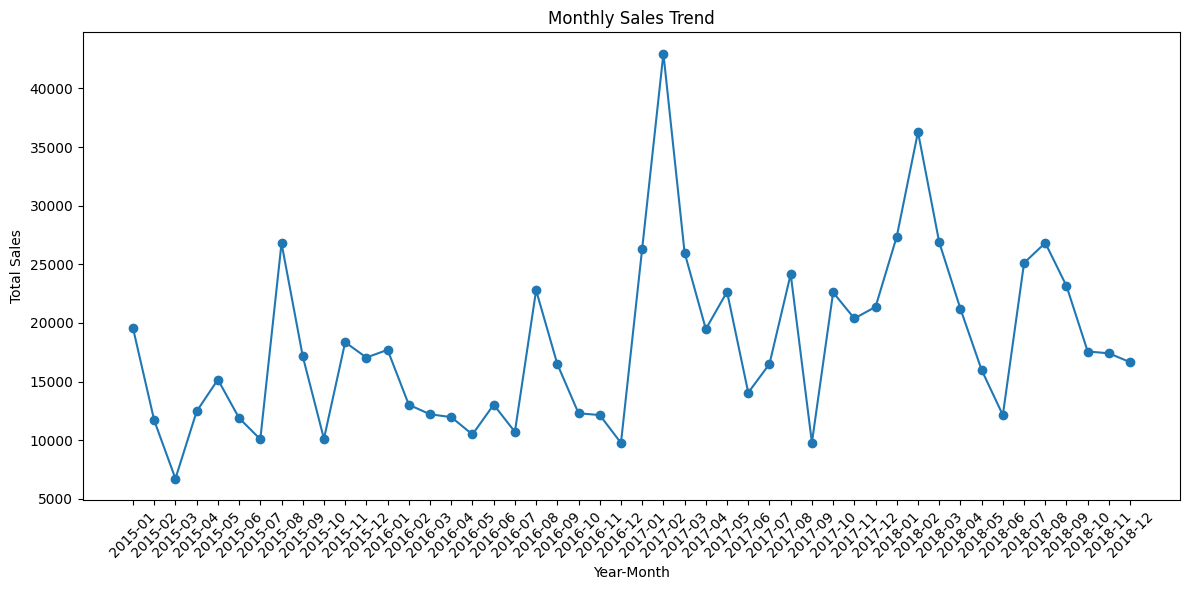

In [23]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Year-Month'], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()


In [24]:
#sales by region
sales_by_region = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

Region
West       271156.6335
East       246227.6310
Central    208805.0696
South      146173.7895
Name: Sales, dtype: float64

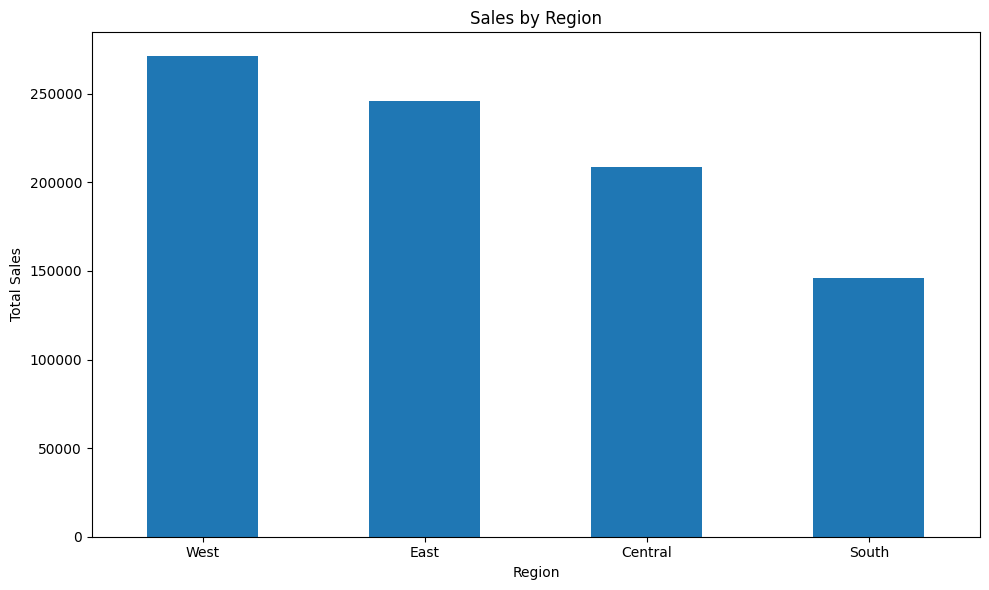

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
#Top 10 Product by Sub cato
sales_by_subcategory = (
    df_clean.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sales_by_subcategory


Sub-Category
Phones         124533.0920
Chairs         122626.9450
Tables          88768.3035
Storage         84433.2060
Machines        83658.1960
Accessories     69913.6800
Binders         64742.9220
Copiers         55739.1220
Bookcases       41278.8721
Appliances      35826.7490
Name: Sales, dtype: float64

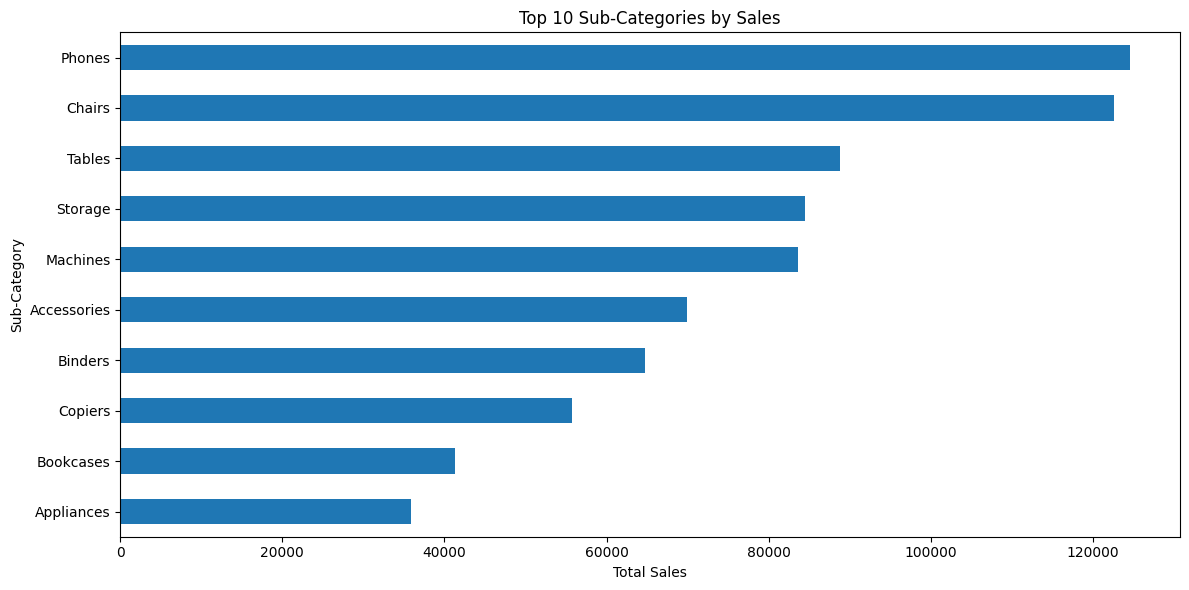

In [27]:
plt.figure(figsize=(12, 6))
sales_by_subcategory.sort_values().plot(kind="barh")
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.savefig("../images/top_10_subcategories.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
total_sales = df_clean["Sales"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 872363.12
Total Orders: 1975
Total Customers: 736


In [30]:
#sales by cust segment
sales_by_segment = (
    df_clean.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

Segment
Consumer       431199.9950
Corporate      263710.1641
Home Office    177452.9645
Name: Sales, dtype: float64

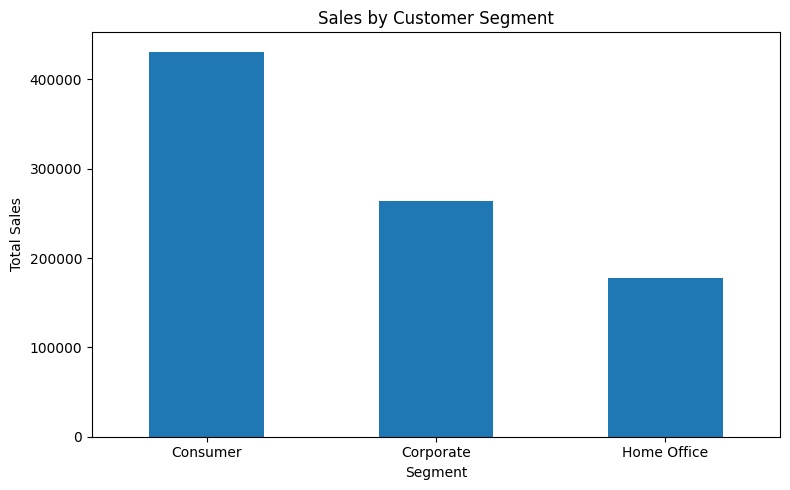

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sales_by_segment.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/sales_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
#top 10 sales by state
top_states = (
    df_clean.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State
California        176044.3455
New York          123666.8900
Texas              81508.0546
Washington         52058.2540
Pennsylvania       36392.2290
Florida            33567.9305
Virginia           32331.6400
Indiana            31104.4800
North Carolina     28390.6610
Michigan           26912.3310
Name: Sales, dtype: float64

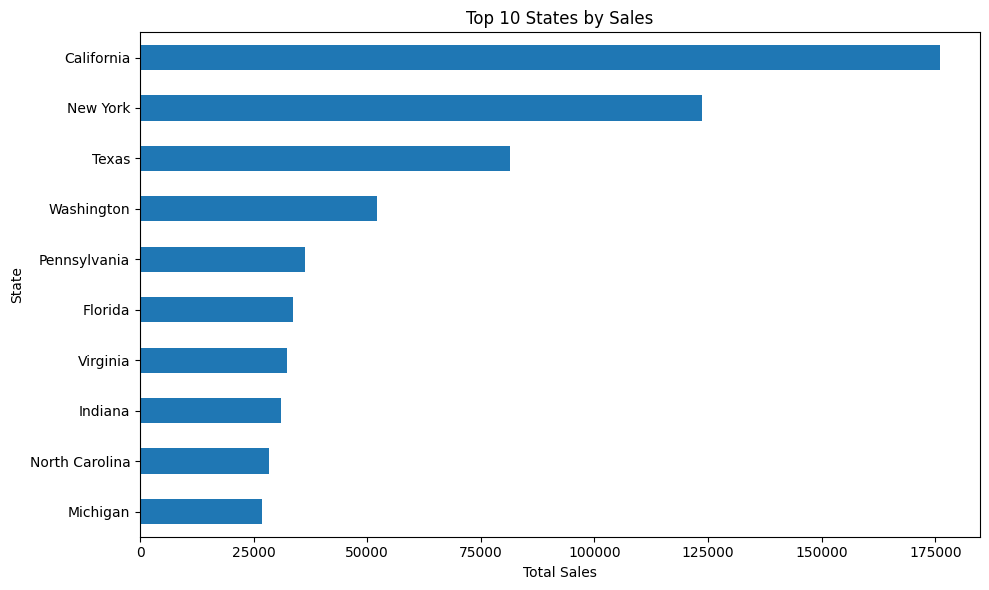

In [33]:
plt.figure(figsize=(10, 6))
top_states.sort_values().plot(kind="barh")
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../images/top_10_states.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
#KPI per order
average_sales_per_order = total_sales / total_orders
print("Average Sales per Order:", round(average_sales_per_order, 2))

Average Sales per Order: 441.7


In [35]:
#top 10 product by sales 
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                            17499.9500
Lexmark MX611dhe Monochrome Laser Printer                        11219.9340
HP Designjet T520 Inkjet Large Format Printer - 24" Color         8749.9500
GBC DocuBind TL300 Electric Binding System                        8521.4050
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish     8298.8316
Hewlett Packard LaserJet 3310 Copier                              8159.8640
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back       8148.9320
Cubify CubeX 3D Printer Triple Head Print                         7999.9800
Zebra ZM400 Thermal Label Printer                                 6965.7000
HON 5400 Series Task Chairs for Big and Tall                      6589.2120
Name: Sales, dtype: float64

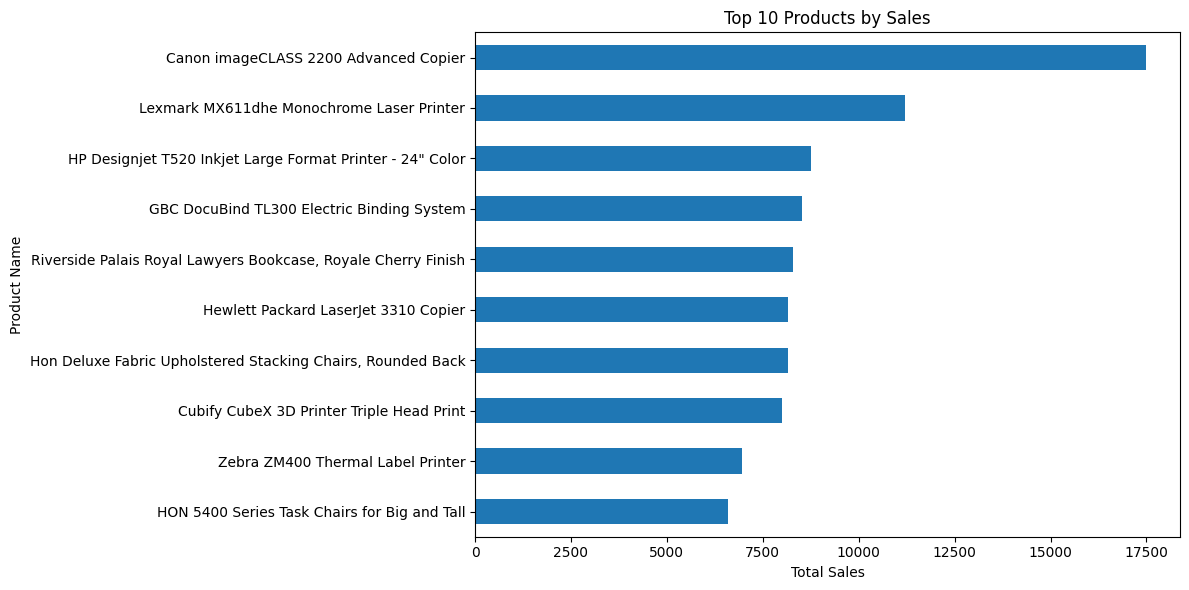

In [36]:
plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.savefig("../images/top_10_products.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
df_raw[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [59]:
import pandas as pd

df_fresh = pd.read_csv("../data/sales.csv")
df_fresh.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [60]:
df_fresh["Order Date"] = pd.to_datetime(df_fresh["Order Date"], dayfirst=True, errors="coerce")
df_fresh["Ship Date"] = pd.to_datetime(df_fresh["Ship Date"], dayfirst=True, errors="coerce")
df_fresh["Sales"] = pd.to_numeric(df_fresh["Sales"], errors="coerce")

In [61]:
df_fresh = df_fresh.drop_duplicates()
df_fresh = df_fresh.dropna(subset=["Order Date", "Sales", "Region", "Category"])

In [62]:
df_fresh["Shipping Delay Days"] = (
    df_fresh["Ship Date"] - df_fresh["Order Date"]
).dt.days

df_fresh[["Order Date", "Ship Date", "Shipping Delay Days"]].head(10)

,Order Date,Ship Date,Shipping Delay Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7
5,2015-06-09,2015-06-14,5
6,2015-06-09,2015-06-14,5
7,2015-06-09,2015-06-14,5
8,2015-06-09,2015-06-14,5
9,2015-06-09,2015-06-14,5


In [63]:
df_fresh["Shipping Delay Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Delay Days, dtype: float64

In [65]:
shipping_delay_by_mode = (
    df_fresh.groupby("Ship Mode")["Shipping Delay Days"]
    .mean()
    .sort_values(ascending=False)
)

shipping_delay_by_mode

Ship Mode
Standard Class    5.008363
Second Class      3.249211
First Class       2.179214
Same Day          0.044610
Name: Shipping Delay Days, dtype: float64

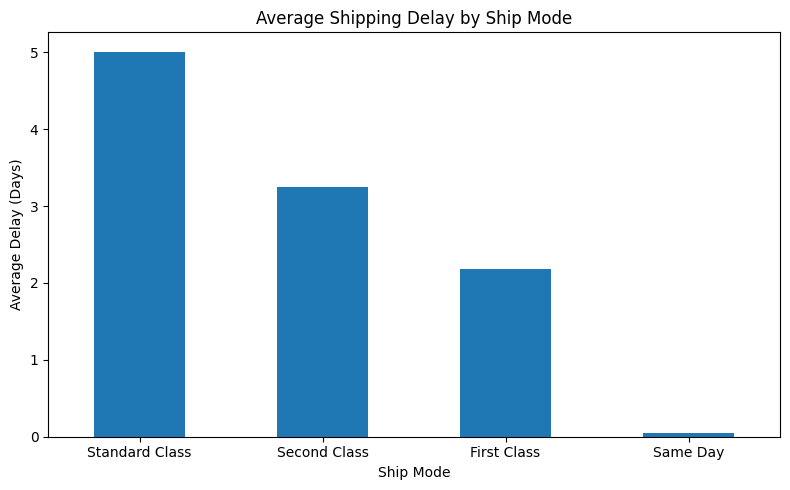

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
shipping_delay_by_mode.plot(kind="bar")
plt.title("Average Shipping Delay by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/shipping_delay_by_mode.png", dpi=300, bbox_inches="tight")
plt.show()

In [67]:
df_clean = df_fresh.copy()

In [68]:
df_clean.to_csv("../data/sales_cleaned.csv", index=False)
print("Corrected cleaned dataset saved.")

Corrected cleaned dataset saved.
